In [1]:
#Install Dependencies
print("Installing dependencies - Started")

!pip install -qU \
    langchain \
    langchain-community \
    langchain-groq \
    langchain-huggingface \
    pymupdf \
    python-dotenv \
    ipywidgets \
    langsmith \
    pandas \
    requests>=2.32.5 \
    pydantic==2.12.3

!pip install ipython

!pip install streamlit
print("Installing dependencies - Completed")

Installing dependencies - Started
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.55.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
  Attempting uninstall: pa

In [2]:
#Setup API Keys
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "IntelligentDocumentProcessor"

In [3]:

#Imports

import os
import csv
import json
import sqlite3
from datetime import datetime
from typing import TypedDict, Optional, Literal, Dict, Any

import fitz
import pandas as pd

from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

In [4]:

#LangGraph state

class DocumentState(TypedDict, total=False):
    document_path: str
    document_name: str
    received_date: str
    raw_text: str
    classification: str
    confidence: float
    explanation: str
    sender_name: Optional[str]
    account_number: Optional[str]
    request_summary: str
    extracted_details: Dict[str, Any]
    final_decision: str
    route: str
    status: str

In [5]:
#Pydantic Class for Result Schema
class ClassificationResult(BaseModel):
    classification: Literal["Cease", "Uncertain", "Irrelevant"] = Field(
        description="Document category"
    )
    confidence: float = Field(description="Confidence score from 0 to 1")
    explanation: str = Field(description="Short explanation for the decision")
    sender_name: Optional[str] = Field(default=None, description="Extracted sender/customer name")
    account_number: Optional[str] = Field(default=None, description="Extracted account/reference number")
    request_summary: Optional[str] = Field(default=None, description="Short summary of the document")
    extracted_details: Dict[str, Any] = Field(default_factory=dict, description="Other extracted details")

In [6]:
# Initialize Groq model

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="parsed"
)


structured_llm = llm.with_structured_output(ClassificationResult)
print("Groq model initialized.")

Groq model initialized.


In [7]:
#Directory Setup

BASE_DIR = "/content/U855316_CapstoneProject"
INPUT_DIR = os.path.join(BASE_DIR, "input_docs")
ARCHIVE_DIR = os.path.join(BASE_DIR, "archive")
AUDIT_DIR = os.path.join(BASE_DIR, "audit")
DB_DIR = os.path.join(BASE_DIR, "db")

for path in [BASE_DIR, INPUT_DIR, ARCHIVE_DIR, AUDIT_DIR, DB_DIR]:
    os.makedirs(path, exist_ok=True)

DB_PATH = os.path.join(DB_DIR, "cease_requests.db")
ARCHIVE_CSV = os.path.join(ARCHIVE_DIR, "irrelevant_documents.csv")
AUDIT_LOG = os.path.join(AUDIT_DIR, "audit_log.jsonl")
HUMAN_REVIEW_PAYLOAD_FILE = os.path.join(BASE_DIR, "human_review_payload.json")
HUMAN_REVIEW_RESULT_FILE = os.path.join(BASE_DIR, "human_review_result.json")

print("BASE_DIR:", BASE_DIR)
print("DB_PATH:", DB_PATH)
print("ARCHIVE_CSV:", ARCHIVE_CSV)
print("AUDIT_LOG:", AUDIT_LOG)

BASE_DIR: /content/U855316_CapstoneProject
DB_PATH: /content/U855316_CapstoneProject/db/cease_requests.db
ARCHIVE_CSV: /content/U855316_CapstoneProject/archive/irrelevant_documents.csv
AUDIT_LOG: /content/U855316_CapstoneProject/audit/audit_log.jsonl


In [8]:

# Upload documents to be processed

from google.colab import files
import shutil

uploaded = files.upload()

for filename in uploaded.keys():
    if os.path.exists(filename):
        shutil.move(filename, os.path.join(INPUT_DIR, filename))

print("Uploaded files moved.")
print(os.listdir(INPUT_DIR))

Uploaded files moved.
['LOA_Uncertain.pdf', 'LOA_scanned.pdf', '.ipynb_checkpoints', 'LOA_Cease.pdf', 'Irrelavant.pdf']


In [9]:

#Initialize database and files

def init_db():
    conn = sqlite3.connect(DB_PATH)
    print("Connected")
    cur = conn.cursor()
    cur.execute(
        '''
        CREATE TABLE IF NOT EXISTS cease_requests (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            received_date TEXT,
            document_name TEXT,
            sender_name TEXT,
            account_number TEXT,
            request_summary TEXT,
            extracted_details_json TEXT,
            classification TEXT,
            confidence REAL,
            processed_at TEXT
        )
        '''
    )
    conn.commit()
    conn.close()

def init_archive_csv():
    if not os.path.exists(ARCHIVE_CSV):
        with open(ARCHIVE_CSV, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["received_date", "document_name", "classification", "processed_at"])

def init_audit_log():
    if not os.path.exists(AUDIT_LOG):
        open(AUDIT_LOG, "a", encoding="utf-8").close()

init_db()
init_archive_csv()
init_audit_log()

print("Storage initialized.")




Connected
Storage initialized.


In [10]:
# Installing Packages for Scanned Docs

import shutil
import subprocess

print('Installing poppler-utils...')

subprocess.run(['apt-get', 'install', '-y', 'poppler-utils'], check=True)

print('Installing pdf2image...')

subprocess.run(['pip', 'install', 'pdf2image'], check=True)

try:
    import pdf2image
    poppler_path = shutil.which('pdftoppm')
    if poppler_path:
        print(f'Verification Successful: pdf2image imported and pdftoppm found at {poppler_path}')
    else:
        print('Verification Warning: pdftoppm utility not found in PATH.')
except ImportError:
    print('Verification Failed: pdf2image library not found.')

Installing poppler-utils...
Installing pdf2image...
Verification Successful: pdf2image imported and pdftoppm found at /usr/bin/pdftoppm


In [11]:
# pytesseract setup

!apt-get update
!apt-get install -y tesseract-ocr libtesseract-dev
!pip install pytesseract

import pytesseract

try:
    version = pytesseract.get_tesseract_version()
    print(f'Verification Successful: Tesseract OCR version {version} is installed and accessible via pytesseract.')
except Exception as e:
    print(f'Verification Failed: {e}')

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 6,555 B in 2s (2,643 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libtesseract-dev is already the newest version (4.

In [12]:

#Utilities

def now_iso() -> str:
    return datetime.utcnow().isoformat()

def extract_text_from_pdf(pdf_path: str) -> str:
    doc = fitz.open(pdf_path)
    pages = []
    for page in doc:
        pages.append(page.get_text("text"))
    doc.close()
    return "\n".join(pages).strip()

def truncate_text(text: str, max_chars: int = 12000) -> str:
    return text[:max_chars]

def log_audit(event: dict):
    with open(AUDIT_LOG, "a", encoding="utf-8") as f:
        f.write(json.dumps(event, ensure_ascii=False) + "\n")

def insert_cease_request(
    received_date: str,
    document_name: str,
    sender_name: Optional[str],
    account_number: Optional[str],
    request_summary: str,
    extracted_details: dict,
    classification: str,
    confidence: float,
):
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute(
        '''
        INSERT INTO cease_requests (
            received_date, document_name, sender_name, account_number,
            request_summary, extracted_details_json, classification, confidence, processed_at
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''',
        (
            received_date,
            document_name,
            sender_name,
            account_number,
            request_summary,
            json.dumps(extracted_details, ensure_ascii=False),
            classification,
            confidence,
            now_iso(),
        )
    )
    conn.commit()
    conn.close()

def append_irrelevant_archive(received_date: str, document_name: str, classification: str):
    with open(ARCHIVE_CSV, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([received_date, document_name, classification, now_iso()])

def write_human_review_payload(payload: dict):
    with open(HUMAN_REVIEW_PAYLOAD_FILE, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

def read_human_review_result() -> dict:
    if not os.path.exists(HUMAN_REVIEW_RESULT_FILE):
        raise FileNotFoundError(
            f"{HUMAN_REVIEW_RESULT_FILE} not found. Complete the review in UI first."
        )
    with open(HUMAN_REVIEW_RESULT_FILE, "r", encoding="utf-8") as f:
        return json.load(f)


In [13]:
#Agent nodes
import os

#Loader Agent
def loader_agent(state: DocumentState) -> DocumentState:
    text = extract_text_from_pdf(state["document_path"])

    if not text.strip():
        log_audit({
            "timestamp": now_iso(),
            "agent": "loader_agent",
            "document_name": state["document_name"],
            "action": "detection_failed",
            "status": "ocr_required",
        })
        return {**state, "raw_text": "", "status": "ocr_required", "route": "vision_extraction_agent"}

    log_audit({
        "timestamp": now_iso(),
        "agent": "loader_agent",
        "document_name": state["document_name"],
        "action": "loaded_document",
        "status": "success",
    })
    return {**state, "raw_text": text, "status": "loaded", "route": "classification_agent"}

#Classification Agent
def classification_agent(state: DocumentState) -> DocumentState:
    text = truncate_text(state["raw_text"])

    if text == "NO_TEXT_EXTRACTED":
        explanation = "No text could be extracted from this document. Human review required."
        return {
            **state,
            "classification": "Uncertain",
            "confidence": 0.0,
            "explanation": explanation,
            "route": "Uncertain",
            "status": "classified",
        }

    prompt = """
You are an extremely meticulous, objective, and expert compliance document classification agent.

Your primary task is to rigorously analyze the provided document and classify it into one and *only one* of the following three categories. Your classification must be based solely on the explicit content of the document. Do not make assumptions or infer intent not explicitly stated.

Categories:
1. Cease - This category is *only* for documents containing a clear, unambiguous, and explicit request to stop direct communication, contact, marketing, or collection efforts concerning a specific entity or account.
2. Uncertain - This category is for documents that are ambiguous, incomplete, contain low-confidence indicators, conflicting information, or represent a possible cease request that is not clear or explicit enough to be classified as 'Cease'. Any doubt defaults to Uncertain.
3. Irrelevant - This category is for documents that are clearly not related to a cease request in any way.

Rules for Classification and Extraction:
-   **Strict Adherence to Definitions**: Only classify as 'Cease' if the request is unambiguous, direct, and explicit. Any ambiguity *must* default to 'Uncertain'.
-   **Conservatism**: Err on the side of 'Uncertain' if there is any doubt regarding the intent of a cease request or if critical information is missing or unclear.
-   **Information Extraction**: Systematically attempt to extract the `sender_name`, `account_number`, `request_summary`, and `extracted_details` from the document. If a piece of information is not clearly and explicitly present, leave it as `None` (for strings) or an empty dictionary (for `extracted_details`).
-   **Confidence Score**: Assign a confidence level (0.0 to 1.0) reflecting your certainty in the classification, with 1.0 being absolute certainty and 0.0 being no certainty.
-   **Explanation**: Provide a brief, objective justification for your classification. This explanation should also briefly mention why specific details were or were not extracted if relevant to the classification.

Document text:
{text}
""".format(text=text)

    result = structured_llm.invoke(prompt)

    log_audit({
        "timestamp": now_iso(),
        "agent": "classification_agent",
        "document_name": state["document_name"],
        "action": "classified_document",
        "classification": result.classification,
        "status": "success",
    })

    return {
        **state,
        "classification": result.classification,
        "confidence": float(result.confidence),
        "explanation": result.explanation,
        "sender_name": result.sender_name,
        "account_number": result.account_number,
        "request_summary": result.request_summary,
        "extracted_details": result.extracted_details,
        "route": result.classification,
        "status": "classified",
    }

#HITL Agent
def hitl_agent(state: DocumentState) -> DocumentState:
    # Correctly defining the payload variable within the function scope
    payload = {
        "document_name": state.get("document_name"),
        "classification": state.get("classification"),
        "confidence": state.get("confidence"),
        "explanation": state.get("explanation"),
        "sender_name": state.get("sender_name"),
        "account_number": state.get("account_number"),
        "request_summary": state.get("request_summary"),
        "extracted_details": state.get("extracted_details", {}),
        "text_preview": state.get("raw_text", "")[:4000],
    }

    # Passing individual fields to the UI function
    decision_dict = get_human_decision_ui(
        document_name=payload["document_name"],
        classification=payload["classification"],
        confidence=payload["confidence"],
        explanation=payload["explanation"],
        sender_name=payload["sender_name"],
        account_number=payload["account_number"],
        request_summary=payload["request_summary"],
        extracted_details=payload["extracted_details"],
        text_preview=payload["text_preview"],
    )

    log_audit({
        "timestamp": now_iso(),
        "agent": "hitl_agent",
        "document_name": state["document_name"],
        "action": "human_review_completed",
        "human_decision": decision_dict['final_decision'],
        "status": "success",
    })

    return {
        **state,
        "final_decision": decision_dict['final_decision'],
        "route": decision_dict['final_decision'],
        "sender_name": decision_dict['sender_name'],
        "account_number": decision_dict['account_number'],
        "request_summary": decision_dict['request_summary'],
        "status": "human_reviewed"
    }

#Database Agent
def database_agent(state: DocumentState) -> DocumentState:
    final_class = state.get("final_decision", state["classification"])
    insert_cease_request(
        received_date=state["received_date"],
        document_name=state["document_name"],
        sender_name=state.get("sender_name"),
        account_number=state.get("account_number"),
        request_summary=state.get("request_summary", ""),
        extracted_details=state.get("extracted_details", {}),
        classification=final_class,
        confidence=float(state.get("confidence", 0.0)),
    )
    return {**state, "status": "stored_in_db"}

#Archiving Agent
def archiving_agent(state: DocumentState) -> DocumentState:
    final_class = state.get("final_decision", state["classification"])
    append_irrelevant_archive(
        received_date=state["received_date"],
        document_name=state["document_name"],
        classification=final_class,
    )
    return {**state, "status": "archived"}

#Audit Agent
def audit_agent(state: DocumentState) -> DocumentState:
    log_audit({
        "timestamp": now_iso(),
        "agent": "audit_agent",
        "document_name": state["document_name"],
        "action": "workflow_completed",
        "status": "success",
    })
    return {**state, "status": "completed"}

In [14]:
#Utility - Extract text from PDF
def extract_text_from_pdf(pdf_path: str) -> str:
    try:
        doc = fitz.open(pdf_path)
        pages = []
        for page in doc:
            pages.append(page.get_text("text"))
        doc.close()
        return "\n".join(pages).strip()
    except Exception as e:
        print(f"Error extracting text layer: {e}")
        return ""



In [15]:
#vision_extraction_agent
import pytesseract
from pdf2image import convert_from_path

def vision_extraction_agent(state: DocumentState) -> DocumentState:
    """
    Local OCR agent using Tesseract to extract text from scanned PDFs.
    """
    doc_name = state["document_name"]
    doc_path = state["document_path"]
    print(f"Performing Local OCR on: {doc_name}")

    try:
        images = convert_from_path(doc_path)

        extracted_pages = []
        for i, image in enumerate(images):
            page_text = pytesseract.image_to_string(image)
            extracted_pages.append(page_text)

        full_text = "\n".join(extracted_pages).strip()

        if not full_text:
            full_text = "NO_TEXT_FOUND_BY_OCR"

        log_audit({
            "timestamp": now_iso(),
            "agent": "vision_extraction_agent",
            "document_name": doc_name,
            "action": "ocr_extraction",
            "status": "success",
            "method": "tesseract_local"
        })

        return {
            **state,
            "raw_text": full_text,
            "status": "ocr_completed",
            "route": "classification_agent"
        }

    except Exception as e:
        print(f"Local OCR failed: {str(e)}")
        log_audit({
            "timestamp": now_iso(),
            "agent": "vision_extraction_agent",
            "document_name": doc_name,
            "action": "ocr_extraction",
            "status": "failed",
            "error": str(e)
        })
        return {
            **state,
            "raw_text": "OCR_FAILED",
            "status": "ocr_failed",
            "route": "hitl_agent"
        }

print("Vision extraction agent (Tesseract) defined.")

Vision extraction agent (Tesseract) defined.


In [16]:

#Routing

def route_after_classification(state: DocumentState) -> str:
    if state["route"] == "Cease":
        return "database_agent"
    elif state["route"] == "Irrelevant":
        return "archiving_agent"
    return "hitl_agent"

def route_after_hitl(state: DocumentState) -> str:
    if state["route"] == "Cease":
        return "database_agent"
    return "archiving_agent"

def route_after_loader(state: DocumentState) -> str:
    if state["route"] == "vision_extraction_agent":
        return "vision_extraction_agent"
    return "classification_agent"


In [17]:
# Build LangGraph

workflow = StateGraph(DocumentState)

workflow.add_node("loader_agent", loader_agent)
workflow.add_node("vision_extraction_agent", vision_extraction_agent)
workflow.add_node("classification_agent", classification_agent)
workflow.add_node("hitl_agent", hitl_agent)
workflow.add_node("database_agent", database_agent)
workflow.add_node("archiving_agent", archiving_agent)
workflow.add_node("audit_agent", audit_agent)

workflow.set_entry_point("loader_agent")

workflow.add_conditional_edges(
    "loader_agent",
    route_after_loader,
    {
        "vision_extraction_agent": "vision_extraction_agent",
        "classification_agent": "classification_agent",
    },
)

workflow.add_edge("vision_extraction_agent", "classification_agent")

workflow.add_conditional_edges(
    "classification_agent",
    route_after_classification,
    {
        "database_agent": "database_agent",
        "archiving_agent": "archiving_agent",
        "hitl_agent": "hitl_agent",
    },
)

workflow.add_conditional_edges(
    "hitl_agent",
    route_after_hitl,
    {
        "database_agent": "database_agent",
        "archiving_agent": "archiving_agent",
    },
)

workflow.add_edge("database_agent", "audit_agent")
workflow.add_edge("archiving_agent", "audit_agent")
workflow.add_edge("audit_agent", END)

app = workflow.compile()
print("Workflow re-compiled successfully.")

Workflow re-compiled successfully.


In [19]:
#HITL Section - Streamlit UI

def get_human_decision_ui(
    document_name: str,
    classification: str,
    confidence: float,
    explanation: str,
    sender_name: str | None,
    account_number: str | None,
    request_summary: str | None,
    extracted_details: dict,
    text_preview: str,
) -> dict:
    payload = {
        "document_name": document_name,
        "classification": classification,
        "confidence": confidence,
        "explanation": explanation,
        "sender_name": sender_name,
        "account_number": account_number,
        "request_summary": request_summary,
        "extracted_details": extracted_details,
        "text_preview": text_preview[:4000],
    }

    write_human_review_payload(payload)

    print("Human review payload created.")
    print("Open the Streamlit UI and submit review.")
    print("Expected result file:", HUMAN_REVIEW_RESULT_FILE)

    return read_human_review_result()

In [18]:
#HITL Section - Input Console

def human_review_prompt(document_name: str, classification: str, confidence: float, explanation: str, sender_name: Optional[str], account_number: Optional[str], request_summary: str, extracted_details: Dict[str, Any], text_preview: str) -> str:
    sender_info = f"Sender Name (Model): {sender_name or 'N/A'}"
    account_info = f"Account Number (Model): {account_number or 'N/A'}"
    summary_info = f"Request Summary (Model): {request_summary or 'N/A'}"
    extracted_details_info = f"Extracted Details (Model): {json.dumps(extracted_details, indent=2, ensure_ascii=False) if extracted_details else 'N/A'}"
    return f"""
HUMAN REVIEW REQUIRED
---------------------
Document: {document_name}

Model Classification: {classification}
Confidence: {confidence:.2f}
Explanation: {explanation}
{sender_info}
{account_info}
{summary_info}
{extracted_details_info}

Preview:
{text_preview[:1200]}

Enter final decision (Cease/Irrelevant) and correct any details below.
""".strip()

def get_human_decision_console(document_name: str, classification: str, confidence: float, explanation: str, sender_name: Optional[str], account_number: Optional[str], request_summary: str, extracted_details: Dict[str, Any], text_preview: str) -> dict:
    print(human_review_prompt(document_name, classification, confidence, explanation, sender_name, account_number, request_summary, extracted_details, text_preview))

    # Get human-corrected values
    corrected_classification = input(f"Enter corrected Classification (Cease/Irrelevant, default: {classification}): ").strip()
    if not corrected_classification: corrected_classification = classification

    corrected_sender_name = input(f"Enter corrected Sender Name (default: {sender_name or 'N/A'}): ").strip()
    if not corrected_sender_name: corrected_sender_name = sender_name

    corrected_account_number = input(f"Enter corrected Account Number (default: {account_number or 'N/A'}): ").strip()
    if not corrected_account_number: corrected_account_number = account_number

    corrected_request_summary = input(f"Enter corrected Request Summary (default: {request_summary or 'N/A'}): ").strip()
    if not corrected_request_summary: corrected_request_summary = request_summary

    while corrected_classification not in {"Cease", "Irrelevant"}:
        print("Please enter exactly: Cease or Irrelevant for corrected classification")
        corrected_classification = input(f"Enter corrected Classification (Cease/Irrelevant, default: {classification}): ").strip()
        if not corrected_classification: corrected_classification = classification

    return {
        "final_decision": corrected_classification,
        "sender_name": corrected_sender_name,
        "account_number": corrected_account_number,
        "request_summary": corrected_request_summary
    }

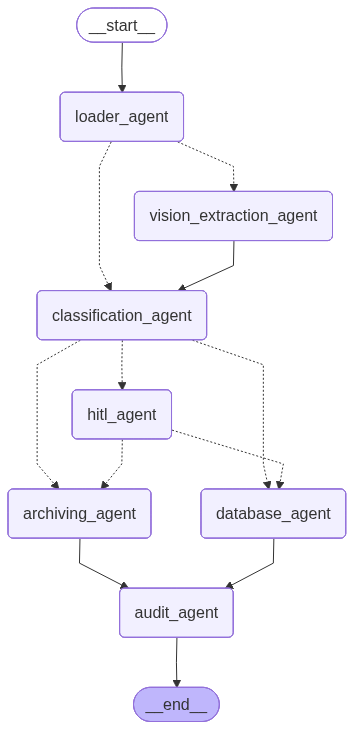

In [20]:
# Display the graph
from IPython.display import Image, display

try:

    graph_png = app.get_graph().draw_mermaid_png()
    display(Image(graph_png))
except Exception as e:
    print(f"Could not display graph: {e}")

In [21]:

#Process Documents

from datetime import datetime, UTC

def now_iso() -> str:
    return datetime.now(UTC).isoformat().replace("+00:00", "Z")

def process_document(pdf_path: str):
    initial_state: DocumentState = {
        "document_path": pdf_path,
        "document_name": os.path.basename(pdf_path),
        "received_date": datetime.now(UTC).date().isoformat(),
    }
    return app.invoke(initial_state)

pdf_files = [
    os.path.join(INPUT_DIR, f)
    for f in os.listdir(INPUT_DIR)
    if f.lower().endswith(".pdf")
]

print("PDF files:", [os.path.basename(x) for x in pdf_files])

results = []

if pdf_files:
    for pdf_path in pdf_files:
        print(f"\nProcessing: {os.path.basename(pdf_path)}")

        try:
            result = process_document(pdf_path)
            print(json.dumps(result, indent=2, default=str))
            results.append(result)

            print("Completed:", os.path.basename(pdf_path))

        except Exception as e:
            print("Error processing:", os.path.basename(pdf_path), "|", str(e))

else:
    print("No PDF files found.")

PDF files: ['LOA_Uncertain.pdf', 'LOA_scanned.pdf', 'LOA_Cease.pdf', 'Irrelavant.pdf']

Processing: LOA_Uncertain.pdf
Human review payload created.
Open the Streamlit UI and submit review.
Expected result file: /content/U855316_CapstoneProject/human_review_result.json
{
  "document_path": "/content/U855316_CapstoneProject/input_docs/LOA_Uncertain.pdf",
  "document_name": "LOA_Uncertain.pdf",
  "received_date": "2026-03-22",
  "raw_text": "Sample 2 - Partial Cease Wording\nCapstone Project - Uncertain Cease Scenario Sample\nDate\n07/11/2025\nAccount/Reference #\n4587-XX\nScenario Type\nUncertain\nDocument Content\nTo Whom It May Concern,\nPlease avoid calling me for now regarding the above matter, as I am currently unavailable and would prefer\nfewer communications until I review everything properly.\nYou may keep the account open while I discuss the issue with my representative. I am not yet sure\nwhether all communication should go through them or only some matters.\nThank you for you

In [22]:
import os

# Create the Streamlit UI script
ui_code = """
import streamlit as st
import json
import os

# Paths from the notebook state
PAYLOAD_FILE = '/content/U855316_CapstoneProject/human_review_payload.json'
RESULT_FILE = '/content/U855316_CapstoneProject/human_review_result.json'

st.set_page_config(page_title="Document Review Tool", layout="wide")
st.title("Compliance Document Human Review")

if not os.path.exists(PAYLOAD_FILE):
    st.warning("No document pending review. Please run the notebook workflow first.")
else:
    with open(PAYLOAD_FILE, 'r') as f:
        payload = json.load(f)

    st.subheader(f"Reviewing: {payload.get('document_name')}")

    col1, col2 = st.columns([1, 1])

    with col1:
        st.info(f"**Model Classification:** {payload.get('classification')} (Confidence: {payload.get('confidence', 0):.2f})")
        st.write(f"**Explanation:** {payload.get('explanation')}")
        st.text_area("Document Text Preview", value=payload.get('text_preview', ''), height=400)

    with col2:
        st.write("### Provide Final Decision")
        final_decision = st.selectbox("Classification", ["Cease", "Irrelevant"],
                                     index=0 if payload.get('classification') == 'Cease' else 1)

        sender_name = st.text_input("Sender Name", value=payload.get('sender_name') or '')
        account_number = st.text_input("Account Number", value=payload.get('account_number') or '')
        request_summary = st.text_area("Request Summary", value=payload.get('request_summary') or '')

        if st.button("Submit Review"):
            result = {
                "final_decision": final_decision,
                "sender_name": sender_name,
                "account_number": account_number,
                "request_summary": request_summary
            }
            with open(RESULT_FILE, 'w') as f:
                json.dump(result, f, indent=2)
            st.success("Review submitted! You can now return to Colab and re-run the process cell.")
            os.remove(PAYLOAD_FILE)
"""

with open('/content/U855316_CapstoneProject/human_review_ui.py', 'w') as f:
    f.write(ui_code)

print("Streamlit UI script updated. Please restart the Streamlit server if needed.")

Streamlit UI script updated. Please restart the Streamlit server if needed.


In [27]:
from google.colab import output
import time
import subprocess
import os

# Kill any existing streamlit processes
!pkill streamlit

# Define the UI path
ui_path = '/content/U855316_CapstoneProject/human_review_ui.py'

# Ensure the payload file exists so the UI has something to show
if not os.path.exists(HUMAN_REVIEW_PAYLOAD_FILE):
    print("Note: No pending review file found. Creating a placeholder...")
    with open(HUMAN_REVIEW_PAYLOAD_FILE, 'w') as f:
        import json
        json.dump({"document_name": "None", "classification": "N/A", "text_preview": "No document loaded."}, f)

# Start Streamlit with specific flags for Colab compatibility
with open('server.log', 'w') as f:
    subprocess.Popen(['streamlit', 'run', ui_path, '--server.port', '8501', '--server.headless', 'true', '--server.enableCORS', 'false', '--server.enableXsrfProtection', 'false'], stdout=f, stderr=f)

print("Starting Streamlit server... waiting 8 seconds for initialization.")
time.sleep(8)

# Display the link and the IFrame
print("If the box below stays empty, try clicking this link:")
output.serve_kernel_port_as_iframe(8501, height='800')


Starting Streamlit server... waiting 8 seconds for initialization.
If the box below stays empty, try clicking this link:


<IPython.core.display.Javascript object>

In [24]:
# 17. View DB records

conn = sqlite3.connect(DB_PATH)
db_df = pd.read_sql_query("SELECT * FROM cease_requests ORDER BY id DESC", conn)
conn.close()

db_df

,id,received_date,document_name,sender_name,account_number,request_summary,extracted_details_json,classification,confidence,processed_at
0,22,2026-03-22,LOA_Cease.pdf,Lovetta Cannunzita,479-44-1808,Cease and desist all communications regarding ...,"{""address"": ""32 DWINELL ST UNIT 187,BUFFALO,CA...",Cease,0.98,2026-03-22T15:08:11.866378Z
1,21,2026-03-22,LOA_Uncertain.pdf,ABC,4587-111-123,Client requests temporary reduction in communi...,"{""communication_preference"": ""Avoid calls unti...",Cease,0.60,2026-03-22T15:07:52.791225Z
2,20,2026-03-22,LOA_Cease.pdf,None,None,Client grants attorney power of attorney and e...,"{""address"": ""32 DWINELL ST UNIT 187, BUFFALO, ...",Cease,0.95,2026-03-22T15:03:20.909373Z
3,19,2026-03-22,LOA_scanned.pdf,"DAVANZO, BELLINA AMOEDO, RADCLIFF","800953896, 800953897",Client authorizes Pinnacle Law Group as agent ...,"{""Client Names"": ""DAVANZO, BELLINA AMOEDO, RAD...",Cease,0.98,2026-03-22T15:03:19.156212Z
4,18,2026-03-22,LOA_Uncertain.pdf,ABC,4587-111-123,Client requests temporary reduction in communi...,"{""client_name"": ""Meena R"", ""communication_pref...",Cease,0.70,2026-03-22T15:03:10.687056Z
5,17,2026-03-22,LOA_Cease.pdf,LOVETTA CANNUNZIATA,None,Explicit cease and desist order with attorney ...,"{""SSN"": ""479-44-1808"", ""attorney_authorization...",Cease,0.95,2026-03-22T14:59:07.488429Z
6,16,2026-03-22,LOA_scanned.pdf,"DAVANZO,BELLINA AMOEDO,RADCLIFF",800953896 800953897,Power of Attorney granting Pinnacle Law Group ...,"{""authorization_scope"": ""Full power to negotia...",Cease,0.98,2026-03-22T14:59:05.932121Z
7,15,2026-03-22,LOA_Cease.pdf,None,___________,Power of attorney granting law firm authority ...,"{""sender_name"": ""LOVETTA CANNUNZIATA"", ""ssn"": ...",Cease,0.95,2026-03-22T14:28:18.581780Z
8,14,2026-03-22,LOA_scanned.pdf,None,"800953896, 800953897",Client grants Pinnacle Law Group power of atto...,"{""agent_name"": ""PINNACLE LAW GROUP"", ""power_of...",Cease,0.95,2026-03-22T14:28:17.414603Z
9,13,2026-03-22,LOA_Cease.pdf,None,___________,Power of attorney granting LAW OFFICES OF DONA...,"{""attorney_authorization"": true, ""sender_name""...",Cease,0.95,2026-03-22T14:25:10.032015Z


In [25]:

# 18. View archive CSV

archive_df = pd.read_csv(ARCHIVE_CSV)
archive_df


,received_date,document_name,classification,processed_at
0,2026-03-22,uncertain_cease_sample_documents.pdf,Irrelevant,2026-03-22T13:40:40.996939Z
1,2026-03-22,LOA_Uncertain.pdf,Irrelevant,2026-03-22T13:50:00.191391Z
2,2026-03-22,Irrelavant.pdf,Irrelevant,2026-03-22T13:50:18.836907Z
3,2026-03-22,LOA_Uncertain.pdf,Irrelevant,2026-03-22T14:01:29.935331Z
4,2026-03-22,Irrelavant.pdf,Irrelevant,2026-03-22T14:01:48.168890Z
5,2026-03-22,LOA_Uncertain.pdf,Irrelevant,2026-03-22T14:13:51.162316Z
6,2026-03-22,Irrelavant.pdf,Irrelevant,2026-03-22T14:25:16.204233Z
7,2026-03-22,LOA_Uncertain.pdf,Irrelevant,2026-03-22T14:28:08.124778Z
8,2026-03-22,Irrelavant.pdf,Irrelevant,2026-03-22T14:28:24.476801Z
9,2026-03-22,LOA_Uncertain.pdf,Irrelevant,2026-03-22T14:58:56.423451Z


In [26]:

#View audit trail

audit_rows = []
with open(AUDIT_LOG, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            audit_rows.append(json.loads(line))

audit_df = pd.DataFrame(audit_rows)
audit_df.tail(50)

,timestamp,agent,document_name,action,status,classification,confidence,explanation,human_decision,method
97,2026-03-22T14:28:17.435351Z,loader_agent,LOA_Cease.pdf,loaded_document,success,NaN,NaN,NaN,NaN,NaN
98,2026-03-22T14:28:18.579300Z,classification_agent,LOA_Cease.pdf,classified_document,success,Cease,NaN,NaN,NaN,NaN
99,2026-03-22T14:28:18.591695Z,audit_agent,LOA_Cease.pdf,workflow_completed,success,NaN,NaN,NaN,NaN,NaN
100,2026-03-22T14:28:18.598140Z,loader_agent,Irrelavant.pdf,detection_failed,ocr_required,NaN,NaN,NaN,NaN,NaN
101,2026-03-22T14:28:23.245668Z,vision_extraction_agent,Irrelavant.pdf,ocr_extraction,success,NaN,NaN,NaN,NaN,tesseract_local
102,2026-03-22T14:28:24.474084Z,classification_agent,Irrelavant.pdf,classified_document,success,Irrelevant,NaN,NaN,NaN,NaN
103,2026-03-22T14:28:24.478409Z,audit_agent,Irrelavant.pdf,workflow_completed,success,NaN,NaN,NaN,NaN,NaN
104,2026-03-22T14:58:54.957459Z,loader_agent,LOA_Uncertain.pdf,loaded_document,success,NaN,NaN,NaN,NaN,NaN
105,2026-03-22T14:58:56.416400Z,classification_agent,LOA_Uncertain.pdf,classified_document,success,Uncertain,NaN,NaN,NaN,NaN
106,2026-03-22T14:58:56.419884Z,hitl_agent,LOA_Uncertain.pdf,human_review_completed,success,NaN,NaN,NaN,Irrelevant,NaN
